# Getting baseline ARIMA model running

## 0.0 Setup

In [171]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [172]:
### MOVE TO REQUIREMENTS ###
# !pip install statsmodels

## 0.1 Data import

Importing electricity price data for Germany from February 2025 to February 2026!

ALERT: Data has to be in raw_data folder!!

In [173]:
path = "../../raw_data/"
file = "combined_energy_price_clean.csv"
route = path + file

In [185]:
data = pd.read_csv(route, sep='\t')

/var/folders/sj/pc75w_ds6w72_p6qqgqy9m980000gn/T/ipykernel_29841/2900955338.py:1: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(route, sep='\t')


In [186]:
data = data[["DateTime(UTC)", "Price[Currency/MWh]","Sequence"]]

In [187]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 378307 entries, 0 to 378306
Data columns (total 3 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   DateTime(UTC)        378307 non-null  object 
 1   Price[Currency/MWh]  378307 non-null  float64
 2   Sequence             378307 non-null  object 
dtypes: float64(1), object(2)
memory usage: 8.7+ MB


## 1.0 Data cleaning

In [188]:
#choosing sequence 2 for 15 minutes intervals
data_2 = data[data["Sequence"] == 2]
data_2.drop(columns="Sequence", inplace=True)
len(data_2)

/var/folders/sj/pc75w_ds6w72_p6qqgqy9m980000gn/T/ipykernel_29841/1307687556.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_2.drop(columns="Sequence", inplace=True)


186230

In [189]:
data_2["date"] = pd.to_datetime(data_2["DateTime(UTC)"], format="%Y-%m-%d %H:%M:%S")
data_2.rename(columns={"Price[Currency/MWh]":"price"}, inplace=True)
data_2.drop(columns="DateTime(UTC)", inplace=True)
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 186230 entries, 131072 to 378306
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   price   186230 non-null  float64       
 1   date    186230 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(1)
memory usage: 4.3 MB


/var/folders/sj/pc75w_ds6w72_p6qqgqy9m980000gn/T/ipykernel_29841/3846443639.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_2["date"] = pd.to_datetime(data_2["DateTime(UTC)"], format="%Y-%m-%d %H:%M:%S")
/var/folders/sj/pc75w_ds6w72_p6qqgqy9m980000gn/T/ipykernel_29841/3846443639.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_2.rename(columns={"Price[Currency/MWh]":"price"}, inplace=True)
/var/folders/sj/pc75w_ds6w72_p6qqgqy9m980000gn/T/ipykernel_29841/3846443639.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice fro

In [190]:
start_date = pd.to_datetime("2025-02-01 00:00:00", format="%Y-%m-%d %H:%M:%S")
end_date = pd.to_datetime("2026-02-01 00:00:00", format="%Y-%m-%d %H:%M:%S")
date_boolean_mask = (data_2["date"] >= start_date) & (data_2["date"] <= end_date)

In [191]:
data_bm = data_2[date_boolean_mask]

<Axes: xlabel='date', ylabel='price'>

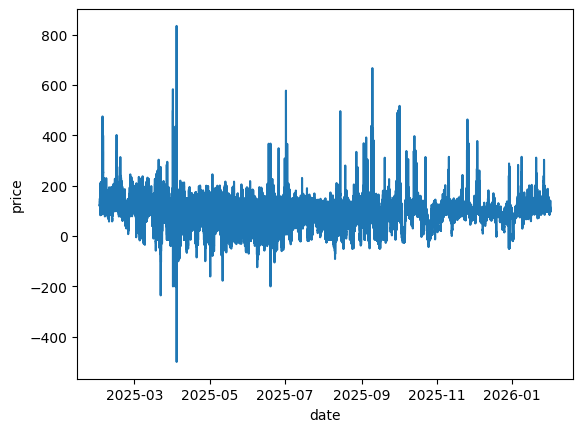

In [192]:
sns.lineplot(data=data_bm, x=data_bm["date"],y=data_bm["price"])

## 2.0 Analysis

### 2.1 Stationarity

In [193]:
X = data_bm["date"]
y = data_bm["price"]

In [194]:
from statsmodels.tsa.stattools import adfuller

df1_result = adfuller(y)[1]
df1_result

np.float64(2.1035424490159925e-30)

### 2.2 AR and MA processes

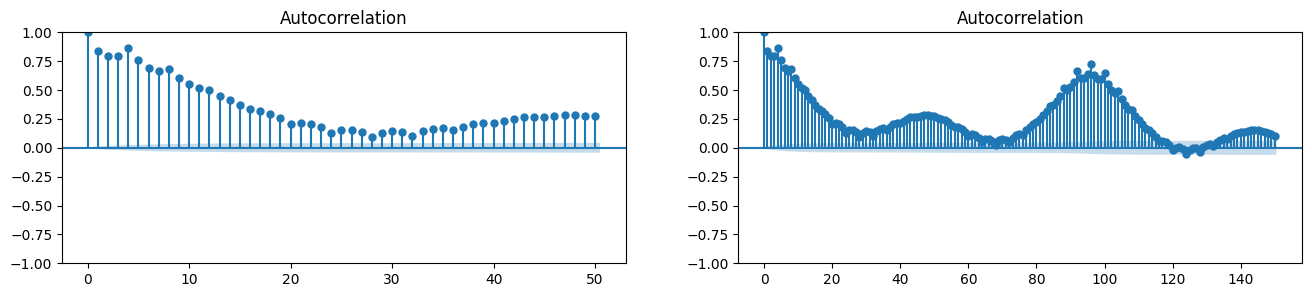

In [195]:
from statsmodels.graphics.tsaplots import plot_acf
fig, axes = plt.subplots(1,2, figsize=(16,3))

plot_acf(y, lags=50, ax=axes[0]);
plot_acf(y, lags=150, ax=axes[1]);

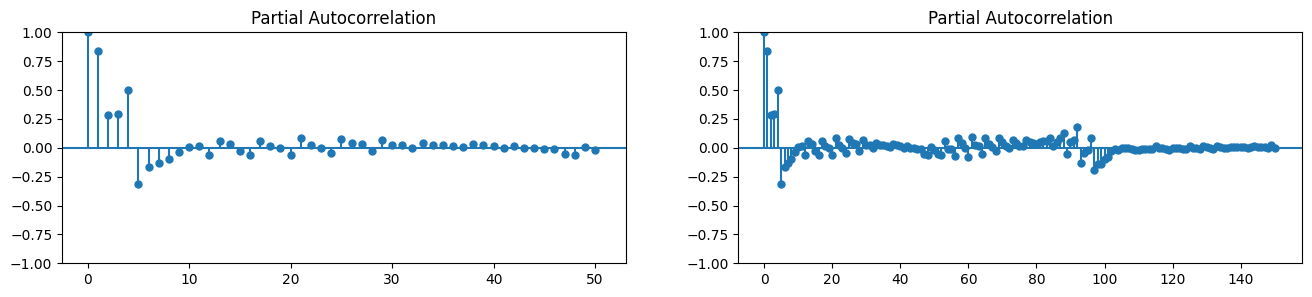

In [196]:
from statsmodels.graphics.tsaplots import plot_pacf
fig, axes = plt.subplots(1,2, figsize=(16,3))

plot_pacf(y, lags=50, ax=axes[0]);
plot_pacf(y, lags=150, ax=axes[1]);

### Notes

Although df1_result is practically 0, we have a lot of significant autocorrelation and partial autocorellation. Such high numbers for p and q as well as their shape (cyclicity) suggest there are a lot of patterns we are not accounting for!

## 3.0 Preliminary model

In [197]:
#a shot in the dark, keep it simple
#preserving the date information
data_bm = data_bm.set_index('date')
#telling the forecast to recognize the index as 15 min intervals
data_bm.index = pd.DatetimeIndex(data_bm.index, freq='15min')

In [ ]:
data_bm.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 35041 entries, 2025-02-01 00:00:00 to 2026-02-01 00:00:00
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   price   35041 non-null  float64
dtypes: float64(1)
memory usage: 547.5 KB


In [198]:
data_bm = data_bm.asfreq('15min')
data_bm = data_bm.interpolate()

In [205]:
data_bm.head()

,price
date,
2025-02-01 00:00:00,145.16
2025-02-01 00:15:00,130.90
2025-02-01 00:30:00,126.30
2025-02-01 00:45:00,120.70
2025-02-01 01:00:00,131.50


In [209]:
from sklearn.model_selection import TimeSeriesSplit
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error
import numpy as np



ts_cv = TimeSeriesSplit(n_splits=5)
mae_list = []

for train_index, test_index in ts_cv.split(data_bm):
    train, test = data_bm.iloc[train_index].copy(), data_bm.iloc[test_index].copy()
    print(f'Lenght train: {len(train)}; Lenght test: {len(test)}')
    # Fit ARIMA on train
    model = ARIMA(train, order=(2,0,2))  # replace with your orders
    model_fit = model.fit()

    # Forecast for test length
    forecast = model_fit.forecast(steps=len(test))

    # Calculate MAE
    mae = mean_absolute_error(test, forecast)
    mae_list.append(mae)

# Average MAE over all folds
avg_mae = np.mean(mae_list)
print(f'Average MAE across folds: {avg_mae}')

Lenght train: 5841; Lenght test: 5840
Lenght train: 11681; Lenght test: 5840
Lenght train: 17521; Lenght test: 5840
Lenght train: 23361; Lenght test: 5840
Lenght train: 29201; Lenght test: 5840
Average MAE across folds: 38.92801836808612


## 4.0 Graph forecast

In [212]:
three_days = 15*24*3

In [213]:
len(data_bm) - three_days

33961

In [258]:
from statsmodels.graphics.tsaplots import plot_predict
# Create a correct train_test_split to predict the last 3 days
train = data_bm['price'][0:33961]
test = data_bm['price'][33961:]

# Build model
arima_model = ARIMA(train, order=(2, 0, 2))
arima_model = arima_model.fit()

In [259]:
# Forecast values
forecast = arima_model.forecast(len(test), alpha=0.05)  # 95% confidence

# Forecast values and confidence intervals
forecast_results = arima_model.get_forecast(len(test), alpha=0.05)
forecast = forecast_results.predicted_mean
confidence_int = forecast_results.conf_int().values

/Users/laurenzpfleiderer/.pyenv/versions/3.10.6/envs/grid-intelligence/lib/python3.10/site-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['alpha']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


In [260]:
def plot_forecast(fc, train, test, upper=None, lower=None):
    is_confidence_int = isinstance(upper, np.ndarray) and isinstance(lower, np.ndarray)
    # Prepare plot series
    fc_series = pd.Series(fc, index=test.index)
    lower_series = pd.Series(upper, index=test.index) if is_confidence_int else None
    upper_series = pd.Series(lower, index=test.index) if is_confidence_int else None

    # Plot
    plt.figure(figsize=(10,4), dpi=100)
    plt.plot(train, label='training', color='black')
    plt.plot(test, label='actual', color='black', ls='--')
    plt.plot(fc_series, label='forecast', color='orange')
    if is_confidence_int:
        plt.fill_between(lower_series.index, lower_series, upper_series, color='k', alpha=.15)
    plt.title('Forecast vs Actuals')
    plt.legend(loc='upper left', fontsize=8);

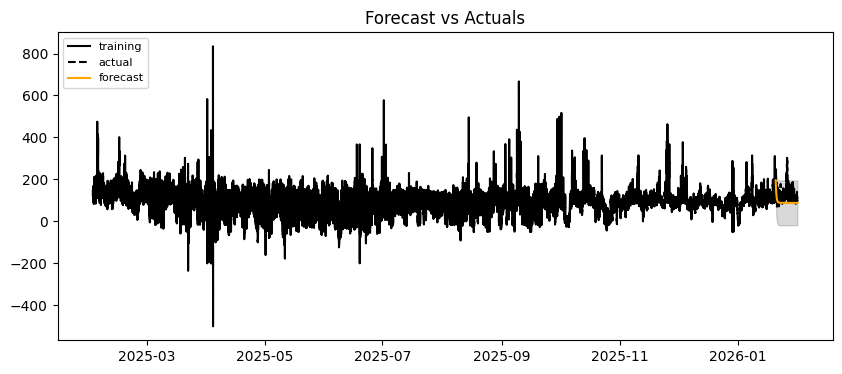

In [261]:
plot_forecast(forecast, train, test, confidence_int[:,0], confidence_int[:,1])

In [262]:
def plot_forecast_2(fc, train, test, ylim_low=None, ylim_up=None,
                    days_shown=None, upper=None, lower=None):
    is_confidence_int = isinstance(upper, np.ndarray) and isinstance(lower, np.ndarray)
    # Prepare plot series
    fc_series = pd.Series(fc, index=test.index)
    lower_series = pd.Series(upper, index=test.index) if is_confidence_int else None
    upper_series = pd.Series(lower, index=test.index) if is_confidence_int else None

    # Plot
    plt.figure(figsize=(10,4), dpi=100)
    plt.plot(train, label='training', color='black')
    plt.plot(test, label='actual', color='black', ls='--')
    plt.plot(fc_series, label='forecast', color='orange')
    if is_confidence_int:
        plt.fill_between(lower_series.index, lower_series, upper_series, color='k', alpha=.15)
    plt.title('Forecast vs Actuals')
    plt.legend(loc='upper left', fontsize=8)
    if days_shown is not None:
        end_date = test.index.max()
        print(end_date)
        start_date = end_date - pd.Timedelta(days=days_shown)
        print(start_date)
        plt.xlim(start_date, end_date)
    if ylim_low is not None and ylim_up is not None:
        plt.ylim(ylim_low, ylim_up)

    plt.show()

2026-02-01 00:00:00
2026-01-12 00:00:00


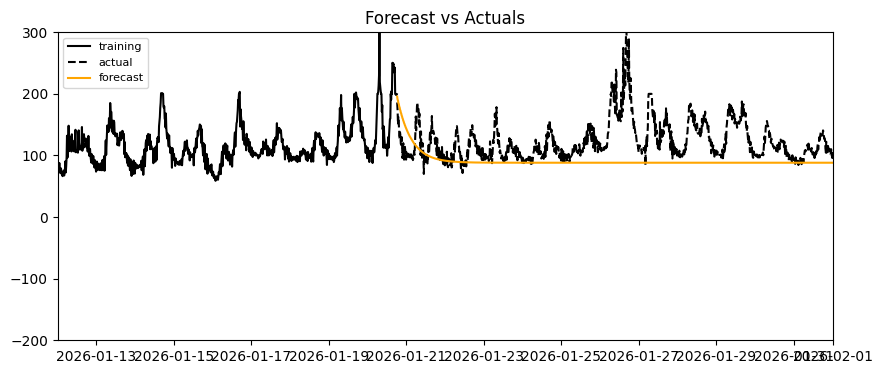

In [263]:
plot_forecast_2(forecast, train, test, ylim_low=-200, ylim_up=300, days_shown=20, upper=None, lower=None)